# Exploración de datos — Riesgo crediticio (Entrega 1)

**Dataset:** *Give Me Some Credit* (`cs-training.csv`)</br>
**Target:** `SeriousDlqin2yrs`</br>
**Pregunta de negocio:** ¿cuál es la probabilidad de incumplimiento grave (mora ≥ 90 días) a 2 años de un solicitante, y cómo usarla para segmentar la aprobación?

## 0. Carga de librerias y de datos

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

RUTA = "../data/raw/cs-training.csv"
df = pd.read_csv(RUTA, index_col=0)

# Nombres más manejables (guardamos el mapeo para el reporte)
df = df.rename(columns={
    "SeriousDlqin2yrs": "incumplio",
    "RevolvingUtilizationOfUnsecuredLines": "utilizacion",
    "age": "edad",
    "NumberOfTime30-59DaysPastDueNotWorse": "moras_30_59",
    "DebtRatio": "razon_deuda",
    "MonthlyIncome": "ingreso_mensual",
    "NumberOfOpenCreditLinesAndLoans": "lineas_abiertas",
    "NumberOfTimes90DaysLate": "moras_90",
    "NumberRealEstateLoansOrLines": "creditos_inmob",
    "NumberOfTime60-89DaysPastDueNotWorse": "moras_60_89",
    "NumberOfDependents": "dependientes",
})
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 150,000 | Columnas: 11


,incumplio,utilizacion,edad,moras_30_59,razon_deuda,ingreso_mensual,lineas_abiertas,moras_90,creditos_inmob,moras_60_89,dependientes
Id,,,,,,,,,,,
1,1,0.77,45,2,0.80,"9,120.00",13,0,6,0,2.00
2,0,0.96,40,0,0.12,"2,600.00",4,0,0,0,1.00
3,0,0.66,38,1,0.09,"3,042.00",2,1,0,0,0.00
4,0,0.23,30,0,0.04,"3,300.00",5,0,0,0,0.00
5,0,0.91,49,1,0.02,"63,588.00",7,0,1,0,0.00


## 1. Estructura general

Una fila corresponde a **un cliente** observado en un punto del tiempo, con su situación y comportamiento crediticio histórico y el resultado de incumplimiento (mora grave sí/no) en los 2 años siguientes. Es un problema de clasificación binaria supervisada clásico de *credit scoring*.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   incumplio        150000 non-null  int64  
 1   utilizacion      150000 non-null  float64
 2   edad             150000 non-null  int64  
 3   moras_30_59      150000 non-null  int64  
 4   razon_deuda      150000 non-null  float64
 5   ingreso_mensual  120269 non-null  float64
 6   lineas_abiertas  150000 non-null  int64  
 7   moras_90         150000 non-null  int64  
 8   creditos_inmob   150000 non-null  int64  
 9   moras_60_89      150000 non-null  int64  
 10  dependientes     146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 13.7 MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
incumplio,"150,000.00",0.07,0.25,0.00,0.00,0.00,0.00,1.00
utilizacion,"150,000.00",6.05,249.76,0.00,0.03,0.15,0.56,"50,708.00"
edad,"150,000.00",52.30,14.77,0.00,41.00,52.00,63.00,109.00
moras_30_59,"150,000.00",0.42,4.19,0.00,0.00,0.00,0.00,98.00
razon_deuda,"150,000.00",353.01,"2,037.82",0.00,0.18,0.37,0.87,"329,664.00"
ingreso_mensual,"120,269.00","6,670.22","14,384.67",0.00,"3,400.00","5,400.00","8,249.00","3,008,750.00"
lineas_abiertas,"150,000.00",8.45,5.15,0.00,5.00,8.00,11.00,58.00
moras_90,"150,000.00",0.27,4.17,0.00,0.00,0.00,0.00,98.00
creditos_inmob,"150,000.00",1.02,1.13,0.00,0.00,1.00,2.00,54.00
moras_60_89,"150,000.00",0.24,4.16,0.00,0.00,0.00,0.00,98.00


Se evidencia un mínimo de Edad (0), se analizará ocurrencia porque no corresponde a una edad mínima aceptable.  Utilizacion y Razon_deuda presentan valores máximo extremadamente altos, lejos de sus medianas (¿miles cuando deberían ser proporciones?) estas variables están expresadas como cocientes. 

## 2. Calidad de datos

In [6]:
# 2.1 Valores faltantes
faltantes = (df.isna().sum().to_frame("n_faltantes")
             .assign(pct=lambda d: 100 * d.n_faltantes / len(df))
             .query("n_faltantes > 0").sort_values("pct", ascending=False))
faltantes

,n_faltantes,pct
ingreso_mensual,29731,19.82
dependientes,3924,2.62


In [11]:
# 2.2 Duplicados
print(f"Filas duplicadas exactas: {df.duplicated().sum():,}")

Filas duplicadas exactas: 609


In [8]:
# 2.3 Valores imposibles y centinelas
print(f"Registros con edad <= 0: {(df.edad <= 0).sum()}")
print(f"Registros con utilizacion > 1: {(df.utilizacion > 1).sum():,} "
      f"({100*(df.utilizacion > 1).mean():.2f}%)")
print(f"Registros con utilizacion > 10: {(df.utilizacion > 10).sum():,}")

for c in ["moras_30_59", "moras_60_89", "moras_90"]:
    n = df[c].isin([96, 98]).sum()
    print(f"Centinelas 96/98 en {c}: {n:,} ({100*n/len(df):.2f}%)")

# ¿Son los mismos registros? (sospecha: sí)
mask_cent = df[["moras_30_59", "moras_60_89", "moras_90"]].isin([96, 98]).any(axis=1)
print(f"\nRegistros con algún centinela: {mask_cent.sum():,}")
print(f"Tasa de incumplimiento en esos registros: {100*df.loc[mask_cent, 'incumplio'].mean():.1f}% "
      f"(vs {100*df.incumplio.mean():.1f}% global)")

Registros con edad <= 0: 1
Registros con utilizacion > 1: 3,321 (2.21%)
Registros con utilizacion > 10: 241
Centinelas 96/98 en moras_30_59: 269 (0.18%)
Centinelas 96/98 en moras_60_89: 269 (0.18%)
Centinelas 96/98 en moras_90: 269 (0.18%)

Registros con algún centinela: 269
Tasa de incumplimiento en esos registros: 54.6% (vs 6.7% global)


In [9]:
# 2.4 ¿El faltante de ingreso es informativo?
tasa_con = df.loc[df.ingreso_mensual.notna(), "incumplio"].mean()
tasa_sin = df.loc[df.ingreso_mensual.isna(), "incumplio"].mean()
print(f"Tasa de incumplimiento CON ingreso reportado: {100*tasa_con:.2f}%")
print(f"Tasa de incumplimiento SIN ingreso reportado: {100*tasa_sin:.2f}%")
# Relación entre ingreso faltante y razon_deuda extrema
df.groupby(df.ingreso_mensual.isna())["razon_deuda"].describe()

Tasa de incumplimiento CON ingreso reportado: 6.95%
Tasa de incumplimiento SIN ingreso reportado: 5.61%


,count,mean,std,min,25%,50%,75%,max
ingreso_mensual,,,,,,,,
False,"120,269.00",26.60,424.45,0.00,0.14,0.30,0.48,"61,106.50"
True,"29,731.00","1,673.40","4,248.37",0.00,123.00,"1,159.00","2,382.00","329,664.00"


El dataset presenta cuatro problemas de calidad con decisiones asociadas: </br>(1) ~20% de faltantes en `ingreso_mensual`: el faltante parece correlacionado con valores atipicos de `razon_deuda`, por lo que imputaremos con mediana y añadiremos un indicador binario de faltante como variable </br>(2) Valores centinela 96/98 en las variables de mora, concentrados en los mismos registros y con tasa de incumplimiento altísima — los trataremos como categoría propia de "moroso crónico" en lugar de eliminarlos, porque son señal, no ruido; </br>(3) Un registro con edad 0, que eliminaremos </br>(4) `utilizacion` con valores extremos que seran estudiados a través de la técnica winsor por encima del percentil 99.

## 3. Variable objetivo y balance de clases

Con esta gráfica se determina las métricas del proyecto

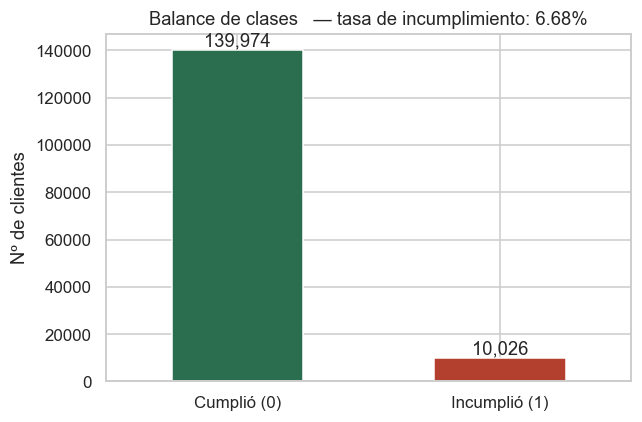

In [14]:
tasa = df.incumplio.mean()
fig, ax = plt.subplots(figsize=(6, 4))
df.incumplio.value_counts().sort_index().plot(kind="bar", ax=ax,
    color=["#2b6e4f", "#b3402e"], rot=0)
ax.set_xticklabels(["Cumplió (0)", "Incumplió (1)"])
ax.set_ylabel("Nº de clientes")
ax.set_title(f"Balance de clases   — tasa de incumplimiento: {100*tasa:.2f}%")
for i, v in enumerate(df.incumplio.value_counts().sort_index()):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); 
plt.show()

Aproximadamente solo 1 de cada 15 clientes incumple aproximadamente 6,7%. Implicaciones directas para el proyecto: (i) el accuracy es una métrica inútil aquí puesto que un modelo que apruebe a todos acierta aproximadamnte 93% sin servir para nada; evaluaremos con AUC-ROC, AUC-PR y recall a precisión fija; (ii) probaremos estrategias de manejo de desbalance (ponderación de clases vs. remuestreo); (iii) el umbral de decisión no será 0,5 sino el que minimice el costo esperado, esto debido a que un falso negativo (aprobar a quien no paga) cuesta  capital y un falso positivo solo el margen